✅ All libraries imported successfully!
Shape: (14996, 8)

First 5 rows:
=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14996 entries, 0 to 14995
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      0 non-null      float64
 1   Age         14996 non-null  int64  
 2   Height      14996 non-null  float64
 3   Weight      14996 non-null  float64
 4   Duration    14996 non-null  float64
 5   Heart_Rate  14996 non-null  float64
 6   Body_Temp   14996 non-null  float64
 7   Calories    14996 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 937.4 KB

=== Statistical Summary ===
       Gender           Age        Height        Weight      Duration  \
count     0.0  14996.000000  14996.000000  14996.000000  14996.000000   
mean      NaN     42.782275    174.461056     74.962390     15.527207   
std       NaN     16.976134     14.257280     15.034239      8.317707   
min       NaN   

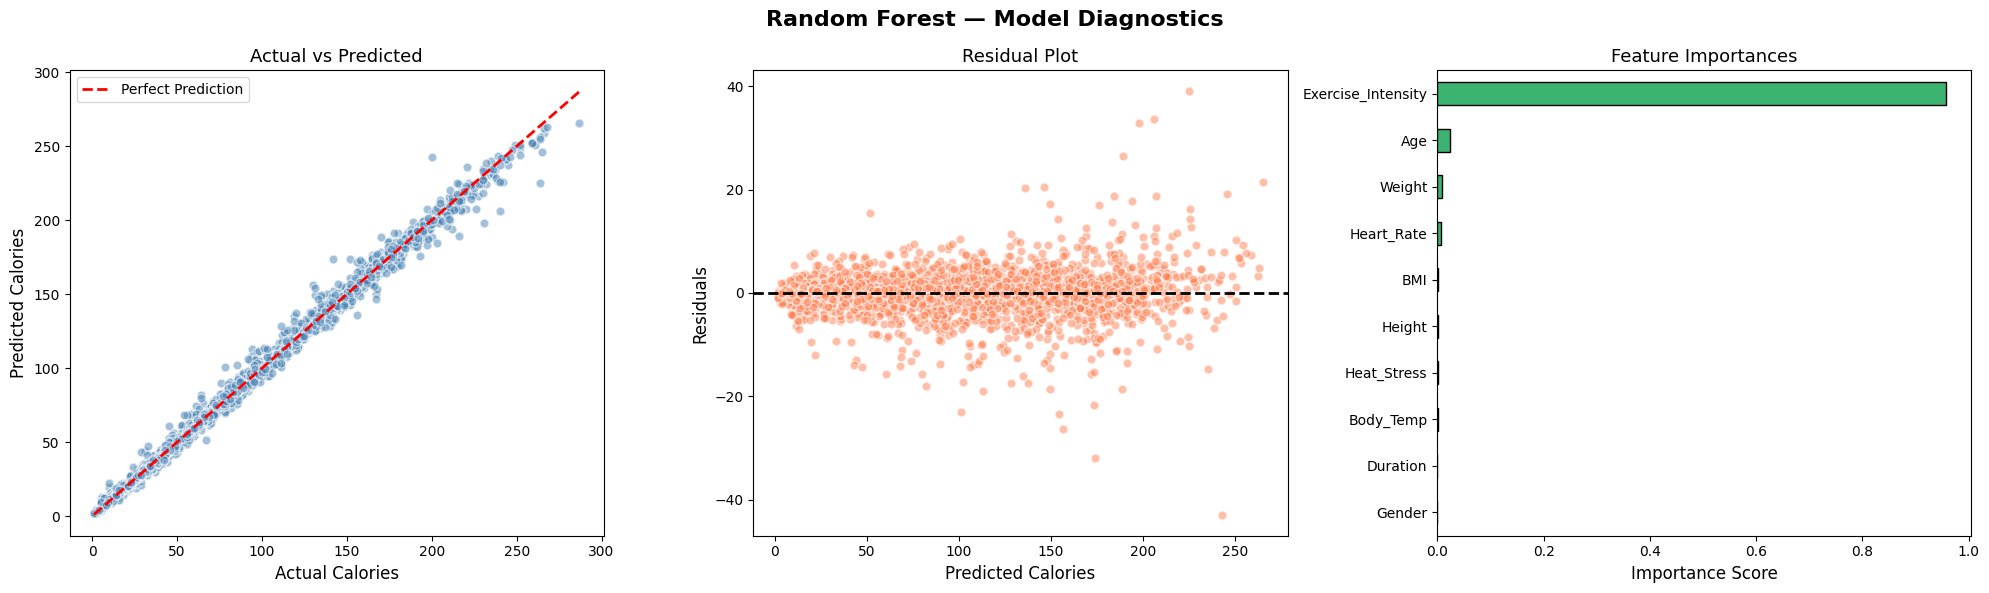

✅ Plots saved as rf_diagnostics.png

=== Feature Importances (Descending) ===
           Feature  Importance  Importance_%
Exercise_Intensity    0.957510         95.75
               Age    0.024661          2.47
            Weight    0.007932          0.79
        Heart_Rate    0.006437          0.64
               BMI    0.001442          0.14
            Height    0.001027          0.10
       Heat_Stress    0.000532          0.05
         Body_Temp    0.000357          0.04
          Duration    0.000103          0.01
            Gender    0.000000          0.00
🔍 Running RandomizedSearchCV — this may take a minute...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 30}
   Best CV R²: 0.9950

  Tuned Random Forest — Evaluation Metrics
  Train R² Score : 0.9990
  Test  R² Score : 0.9959
  MAE            : 2.4224
  MSE            : 15.9255
  RMSE        

In [ ]:

# ============================================================
# CALORIES BURNED PREDICTION — RANDOM FOREST REGRESSION
# Complete End-to-End ML Pipeline
# ============================================================

# ─────────────────────────────────────────────
# CELL 1 — Import Libraries
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("✅ All libraries imported successfully!")

# ─────────────────────────────────────────────
# CELL 2 — Load Dataset
# ─────────────────────────────────────────────
# Update path as needed
df = pd.read_csv("/content/encoded_calories.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

# ─────────────────────────────────────────────
# CELL 3 — Basic Data Exploration
# ─────────────────────────────────────────────
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Column Names ===")
print(df.columns.tolist())

# ─────────────────────────────────────────────
# CELL 4 — Data Preprocessing
# ─────────────────────────────────────────────

# --- Check Null Values ---
print("=== Null Values ===")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

# --- Check Duplicates ---
dups = df.duplicated().sum()
print(f"\n=== Duplicate Rows: {dups} ===")

# --- Remove Duplicates if any ---
if dups > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

# --- Drop unnecessary columns ---
if 'User_ID' in df.columns:
    df.drop(columns=['User_ID'], inplace=True)
    print("Dropped 'User_ID' column.")

print("\nCleaned DataFrame shape:", df.shape)

# ─────────────────────────────────────────────
# CELL 5 — Encode Categorical Features
# ─────────────────────────────────────────────

# Gender: male=1, female=0
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
# male -> 1, female -> 0 (or vice versa based on dataset)

print("Gender encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nSample after encoding:")
print(df[['Gender']].value_counts())

# ─────────────────────────────────────────────
# CELL 6 — Feature Engineering
# ─────────────────────────────────────────────

# BMI = Weight (kg) / Height (m)^2
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# Intensity: Heart_Rate * Duration (proxy for exercise load)
df['Exercise_Intensity'] = df['Heart_Rate'] * df['Duration']

# Temp-Duration interaction (heat stress proxy)
df['Heat_Stress'] = df['Body_Temp'] * df['Duration']

print("=== New Features Added ===")
print(df[['BMI', 'Exercise_Intensity', 'Heat_Stress']].describe())
print("\nDataFrame shape after feature engineering:", df.shape)

# ─────────────────────────────────────────────
# CELL 7 — Define Features and Target
# ─────────────────────────────────────────────

X = df.drop(columns=['Calories'])
y = df['Calories']

print("Feature columns:", X.columns.tolist())
print("\nTarget: Calories")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# ─────────────────────────────────────────────
# CELL 8 — Train-Test Split
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size:   {X_train.shape[0]} samples")
print(f"Testing set size:    {X_test.shape[0]} samples")

# ─────────────────────────────────────────────
# CELL 9 — Feature Scaling
# ─────────────────────────────────────────────
# NOTE: Random Forest is tree-based and does NOT require scaling.
# We scale anyway so the pipeline is compatible if swapping to
# linear models later. It has zero impact on RF performance.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled (StandardScaler).")
print("ℹ️  Note: Scaling does NOT affect Random Forest predictions.")

# ─────────────────────────────────────────────
# CELL 10 — Train Random Forest (Baseline)
# ─────────────────────────────────────────────

# WHY RANDOM FOREST?
# ─ Handles non-linear relationships well
# ─ Robust to outliers compared to linear models
# ─ Provides built-in feature importance scores
# ─ Doesn't require feature scaling
# ─ Reduces overfitting via ensemble of trees (bagging)

rf_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_scaled, y_train)
print("✅ Baseline Random Forest model trained!")

# ─────────────────────────────────────────────
# CELL 11 — Evaluate Baseline Model
# ─────────────────────────────────────────────

def evaluate_model(model, X_tr, X_te, y_tr, y_te, label="Model"):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    train_r2 = r2_score(y_tr, y_pred_train)
    test_r2  = r2_score(y_te, y_pred_test)
    mae      = mean_absolute_error(y_te, y_pred_test)
    mse      = mean_squared_error(y_te, y_pred_test)
    rmse     = np.sqrt(mse)

    print(f"\n{'='*45}")
    print(f"  {label} — Evaluation Metrics")
    print(f"{'='*45}")
    print(f"  Train R² Score : {train_r2:.4f}")
    print(f"  Test  R² Score : {test_r2:.4f}")
    print(f"  MAE            : {mae:.4f}")
    print(f"  MSE            : {mse:.4f}")
    print(f"  RMSE           : {rmse:.4f}")
    print(f"{'='*45}")

    if train_r2 - test_r2 > 0.10:
        print("  ⚠️  Possible OVERFITTING (train R² >> test R²)")
    elif test_r2 < 0.70:
        print("  ⚠️  Possible UNDERFITTING (test R² too low)")
    else:
        print("  ✅ Model generalizes well!")

    return y_pred_test


y_pred_baseline = evaluate_model(
    rf_baseline, X_train_scaled, X_test_scaled,
    y_train, y_test, label="Baseline Random Forest"
)

# ─────────────────────────────────────────────
# CELL 12 — Cross-Validation Check
# ─────────────────────────────────────────────

cv_scores = cross_val_score(rf_baseline, X_train_scaled, y_train,
                             cv=5, scoring='r2')
print(f"\nCross-Validation R² Scores (5-Fold): {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ─────────────────────────────────────────────
# CELL 13 — Visualizations
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Random Forest — Model Diagnostics", fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_baseline, alpha=0.5, color='steelblue', edgecolors='white', s=40)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel("Actual Calories", fontsize=12)
axes[0].set_ylabel("Predicted Calories", fontsize=12)
axes[0].set_title("Actual vs Predicted", fontsize=13)
axes[0].legend()

# Plot 2: Residuals
residuals = y_test - y_pred_baseline
axes[1].scatter(y_pred_baseline, residuals, alpha=0.5, color='coral', edgecolors='white', s=40)
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted Calories", fontsize=12)
axes[1].set_ylabel("Residuals", fontsize=12)
axes[1].set_title("Residual Plot", fontsize=13)

# Plot 3: Feature Importances
feat_imp = pd.Series(rf_baseline.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
feat_imp_sorted.plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title("Feature Importances", fontsize=13)
axes[2].set_xlabel("Importance Score", fontsize=12)

plt.tight_layout()
plt.savefig("rf_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved as rf_diagnostics.png")

# ─────────────────────────────────────────────
# CELL 14 — Feature Importances Table
# ─────────────────────────────────────────────

print("\n=== Feature Importances (Descending) ===")
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_df['Importance_%'] = (fi_df['Importance'] * 100).round(2)
print(fi_df.to_string(index=False))

# INTERPRETATION:
# Higher importance → stronger predictor of calories burned.
# Duration and Heart_Rate typically dominate in exercise datasets.

# ─────────────────────────────────────────────
# CELL 15 — Hyperparameter Tuning (RandomizedSearchCV)
# ─────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.8]
}

rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=param_grid,
    n_iter=30,            # tries 30 random combos
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("🔍 Running RandomizedSearchCV — this may take a minute...")
random_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Params: {random_search.best_params_}")
print(f"   Best CV R²: {random_search.best_score_:.4f}")

# ─────────────────────────────────────────────
# CELL 16 — Evaluate Tuned Model & Compare
# ─────────────────────────────────────────────

best_rf = random_search.best_estimator_

y_pred_tuned = evaluate_model(
    best_rf, X_train_scaled, X_test_scaled,
    y_train, y_test, label="Tuned Random Forest"
)

# Side-by-side comparison
print("\n========= MODEL COMPARISON =========")
print(f"{'Metric':<12} {'Baseline':>12} {'Tuned':>12}")
print("-" * 38)

metrics = {
    'R² Score': (r2_score(y_test, y_pred_baseline), r2_score(y_test, y_pred_tuned)),
    'MAE'     : (mean_absolute_error(y_test, y_pred_baseline), mean_absolute_error(y_test, y_pred_tuned)),
    'RMSE'    : (np.sqrt(mean_squared_error(y_test, y_pred_baseline)),
                 np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
}

for name, (b, t) in metrics.items():
    print(f"{name:<12} {b:>12.4f} {t:>12.4f}")
print("=" * 38)

# ─────────────────────────────────────────────
# CELL 17 — Save the Best Model
# ─────────────────────────────────────────────

joblib.dump(best_rf, "calories_rf_model.pkl")
joblib.dump(scaler,  "calories_scaler.pkl")

print("✅ Model saved as:  calories_rf_model.pkl")
print("✅ Scaler saved as: calories_scaler.pkl")

# ─────────────────────────────────────────────
# CELL 18 — Predict for New Custom Input
# ─────────────────────────────────────────────

# Load saved model & scaler
loaded_model  = joblib.load("calories_rf_model.pkl")
loaded_scaler = joblib.load("calories_scaler.pkl")

# ── Provide new person's data ──────────────────
# Gender: 1 = male, 0 = female (match your LabelEncoder)
new_data = {
    'Gender'    : [1],       # Male
    'Age'       : [28],
    'Height'    : [175],     # cm
    'Weight'    : [75],      # kg
    'Duration'  : [40],      # minutes
    'Heart_Rate': [110],     # bpm
    'Body_Temp' : [40.5]     # °C
}

new_df = pd.DataFrame(new_data)

# Feature engineering (must match training)
new_df['BMI']                = new_df['Weight'] / ((new_df['Height'] / 100) ** 2)
new_df['Exercise_Intensity'] = new_df['Heart_Rate'] * new_df['Duration']
new_df['Heat_Stress']        = new_df['Body_Temp'] * new_df['Duration']

# Ensure column order matches training
new_df = new_df[X.columns]

# Scale and predict
new_scaled = loaded_scaler.transform(new_df)
prediction = loaded_model.predict(new_scaled)

print(f"\n🔮 Predicted Calories Burned: {prediction[0]:.2f} kcal")

# ─────────────────────────────────────────────
# END OF PIPELINE
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("  ✅ Full ML Pipeline Complete!")
print("  Model: Random Forest Regressor")
print("  Output: calories_rf_model.pkl")
print("="*50)


✅ SHAP imported successfully!
✅ SHAP Data Prepared!
✅ SHAP Explainer Created!
✅ SHAP Values Generated!

SHAP Shape:
(2999, 10)


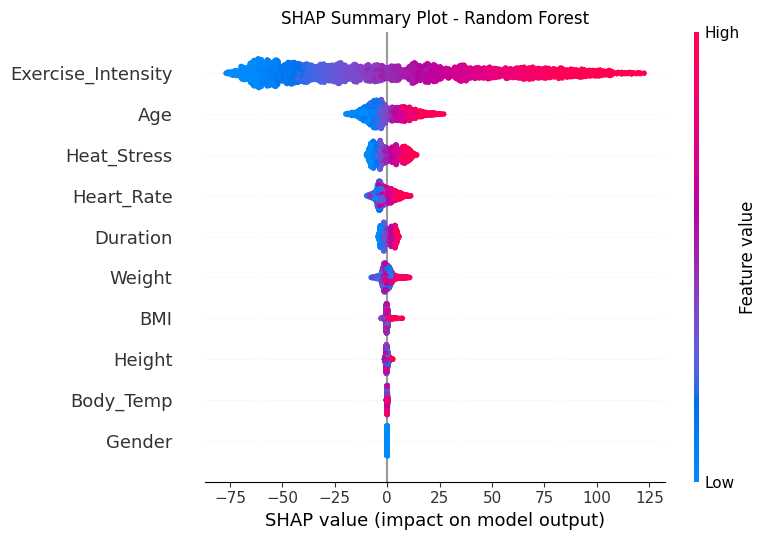

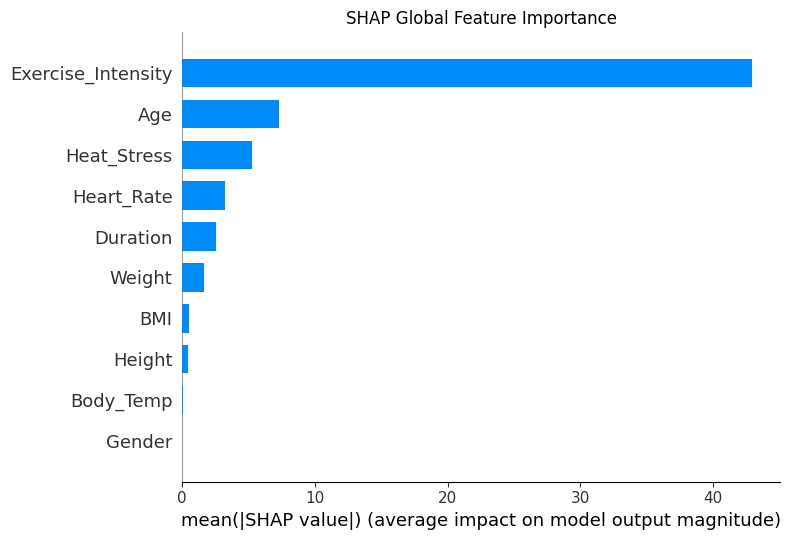

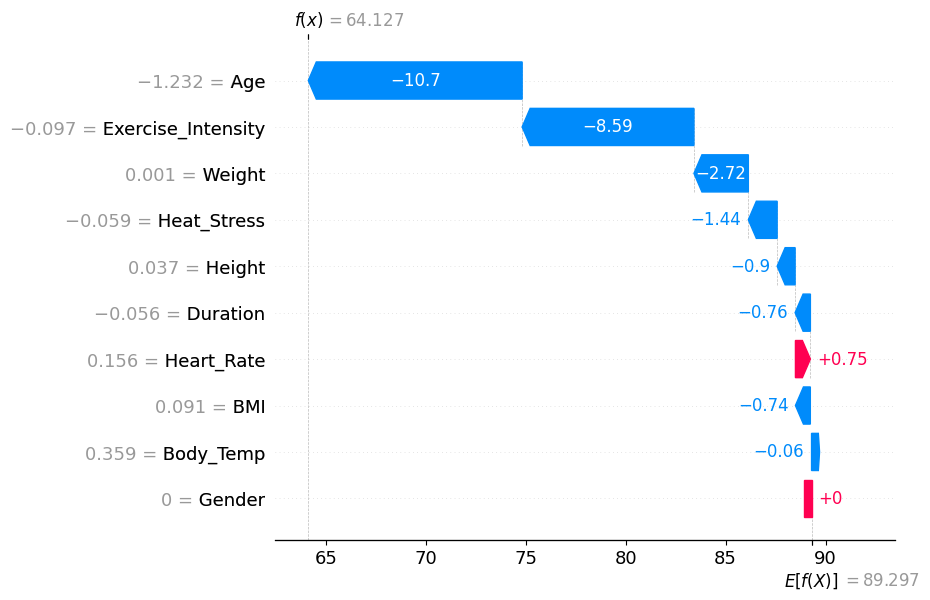

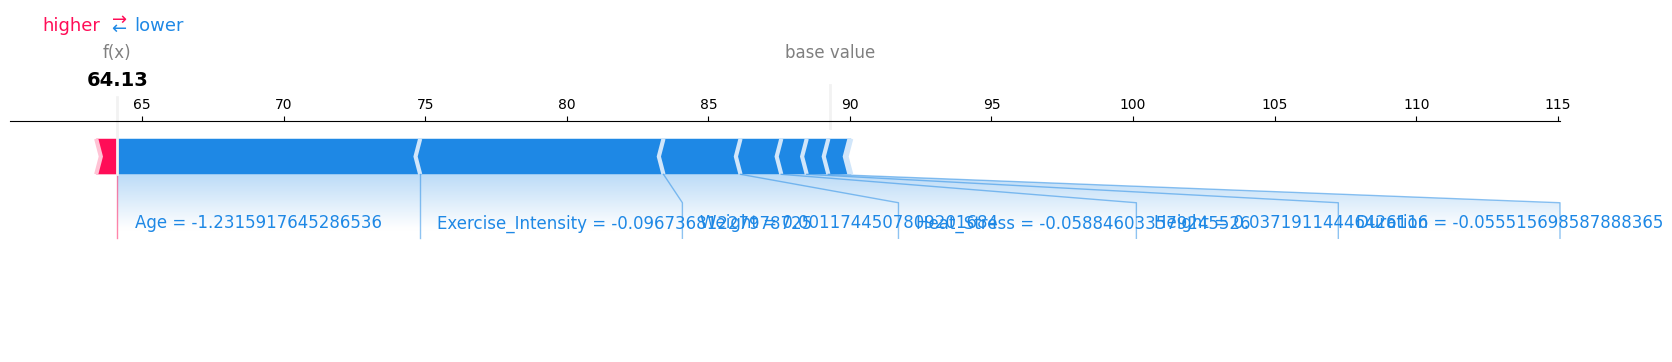


SHAP FEATURE IMPORTANCE
              Feature  SHAP Importance
8  Exercise_Intensity        42.902873
1                 Age         7.268568
9         Heat_Stress         5.282519
5          Heart_Rate         3.202692
4            Duration         2.514710
3              Weight         1.675270
7                 BMI         0.498243
2              Height         0.420800
6           Body_Temp         0.034726
0              Gender         0.000000

RANDOM FOREST vs SHAP IMPORTANCE
              Feature  RF Importance  SHAP Importance
8  Exercise_Intensity       0.798300        42.902873
1                 Age       0.024444         7.268568
9         Heat_Stress       0.107964         5.282519
5          Heart_Rate       0.008900         3.202692
4            Duration       0.049812         2.514710
3              Weight       0.006579         1.675270
7                 BMI       0.002087         0.498243
2              Height       0.001600         0.420800
6           Body_Temp     

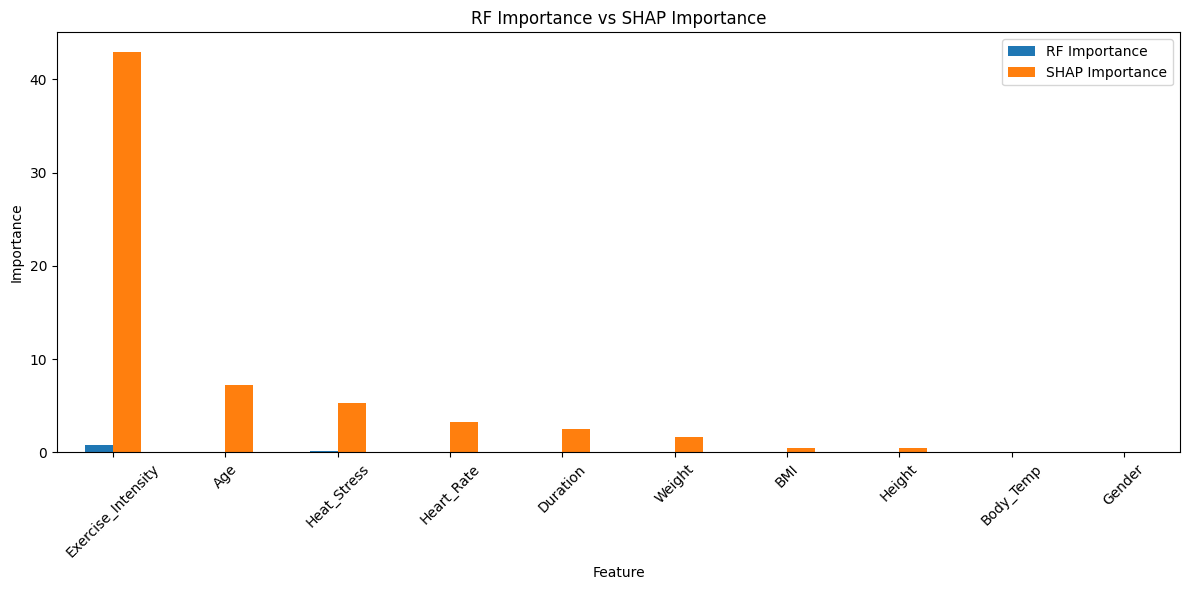

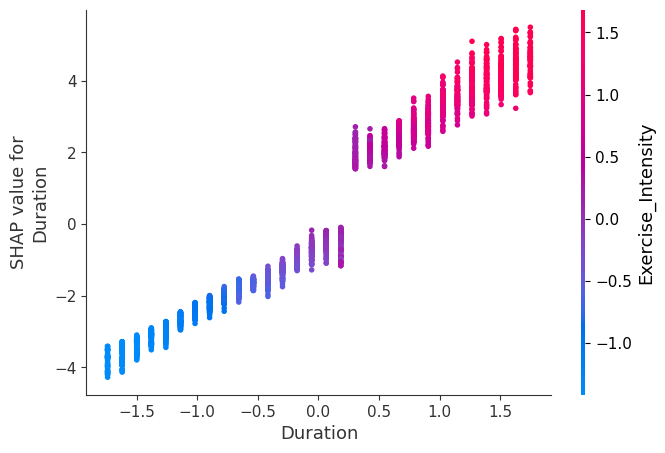

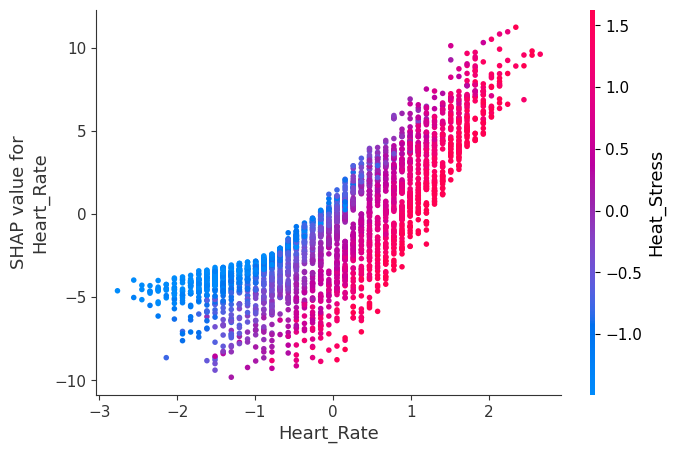

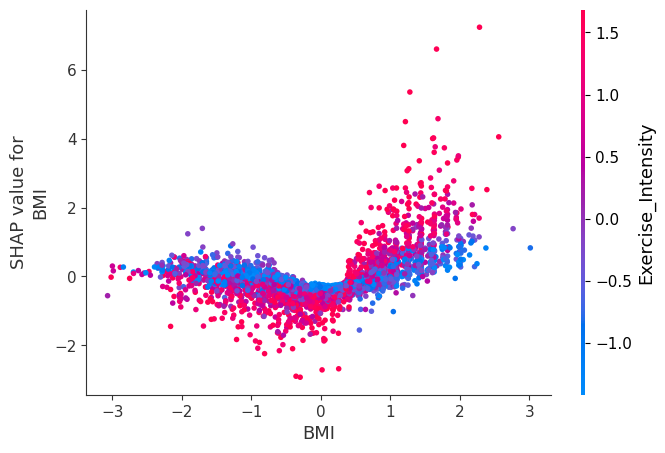


WHAT SHAP VALUES MEAN

SHAP values explain:
How much each feature contributes
to a prediction.

Positive SHAP Value
-------------------
Feature increases predicted calories.

Negative SHAP Value
-------------------
Feature decreases predicted calories.

GLOBAL vs LOCAL INTERPRETABILITY

GLOBAL INTERPRETABILITY
-----------------------
Understands model behavior overall.

Example:
Duration generally increases calories.

Plots:
- Summary Plot
- Bar Plot

LOCAL INTERPRETABILITY
-----------------------
Explains ONE prediction.

Example:
Why one user burned 320 calories.

Plots:
- Waterfall Plot
- Force Plot

CALORIE PREDICTION INTERPRETATION

1. Duration
------------
Usually strongest positive contributor.

Longer workouts increase calorie burn.

2. Heart Rate
--------------
Higher heart rate increases calories burned.

3. BMI
-------
May increase calorie burn because
heavier individuals expend more energy.

4. Exercise_Intensity
---------------------
Higher intensity strongly increases
pr

In [ ]:
# ============================================================
# SHAP EXPLAINABLE AI FOR RANDOM FOREST REGRESSION
# Compatible with YOUR Existing Notebook
# ============================================================

# ============================================================
# CELL 19 — Install & Import SHAP
# ============================================================

# Run ONLY if SHAP is not installed
# !pip install shap

import shap

# Initialize JS visualization
shap.initjs()

print("✅ SHAP imported successfully!")

# ============================================================
# CELL 20 — Prepare Data for SHAP
# ============================================================

"""
IMPORTANT:
Your Random Forest model was trained on:

X_train_scaled
X_test_scaled

So SHAP must also receive scaled data.
"""

# Convert scaled arrays back to DataFrame
X_train_shap = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_shap = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

print("✅ SHAP Data Prepared!")

# ============================================================
# CELL 21 — Create SHAP Explainer
# ============================================================

"""
TreeExplainer is optimized for:
- Random Forest
- XGBoost
- Decision Trees

SHAP explains:
How much each feature contributes
to predictions.
"""

explainer = shap.TreeExplainer(best_rf)

print("✅ SHAP Explainer Created!")

# ============================================================
# CELL 22 — Generate SHAP Values
# ============================================================

shap_values = explainer.shap_values(X_test_shap)

print("✅ SHAP Values Generated!")

print("\nSHAP Shape:")
print(np.array(shap_values).shape)

# ============================================================
# CELL 23 — SHAP Summary Plot
# ============================================================

"""
SUMMARY PLOT
-------------
GLOBAL INTERPRETABILITY

Shows:
- Most important features overall
- Positive vs negative impact
- Distribution of feature influence

Color:
Red  -> High feature value
Blue -> Low feature value

Position:
Right -> Increases calories
Left  -> Decreases calories
"""

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_shap,
    show=False
)

plt.title("SHAP Summary Plot - Random Forest")

plt.tight_layout()

plt.show()

# ============================================================
# CELL 24 — SHAP BAR PLOT
# ============================================================

"""
BAR PLOT
---------
Global feature importance using SHAP values.

Higher value:
More influence on predictions.
"""

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance")

plt.tight_layout()

plt.show()

# ============================================================
# CELL 25 — SHAP WATERFALL PLOT
# ============================================================

"""
WATERFALL PLOT
---------------
LOCAL INTERPRETABILITY

Explains ONE prediction.
"""

sample_index = 0

sample_explanation = shap.Explanation(

    values=shap_values[sample_index],

    base_values=explainer.expected_value,

    data=X_test_shap.iloc[sample_index],

    feature_names=X.columns
)

shap.plots.waterfall(
    sample_explanation,
    max_display=10
)

# ============================================================
# CELL 26 — SHAP FORCE PLOT
# ============================================================

"""
FORCE PLOT
-----------
Interactive explanation.

Red Features:
Push prediction HIGHER

Blue Features:
Push prediction LOWER
"""

shap.force_plot(

    explainer.expected_value,

    shap_values[sample_index],

    X_test_shap.iloc[sample_index],

    matplotlib=True
)

# ============================================================
# CELL 27 — SHAP Feature Importance Table
# ============================================================

shap_importance = pd.DataFrame({

    'Feature': X.columns,

    'SHAP Importance': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(

    by='SHAP Importance',

    ascending=False
)

print("\n======================================")
print("SHAP FEATURE IMPORTANCE")
print("======================================")

print(shap_importance)

# ============================================================
# CELL 28 — Compare RF Importance vs SHAP
# ============================================================

rf_importance = pd.DataFrame({

    'Feature': X.columns,

    'RF Importance': best_rf.feature_importances_
})

comparison_df = pd.merge(

    rf_importance,

    shap_importance,

    on='Feature'
)

comparison_df = comparison_df.sort_values(

    by='SHAP Importance',

    ascending=False
)

print("\n======================================")
print("RANDOM FOREST vs SHAP IMPORTANCE")
print("======================================")

print(comparison_df)

# ============================================================
# CELL 29 — Comparison Plot
# ============================================================

comparison_df.set_index('Feature')[[
    'RF Importance',
    'SHAP Importance'
]].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("RF Importance vs SHAP Importance")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================
# CELL 30 — SHAP Dependence Plots
# ============================================================

"""
DEPENDENCE PLOT
----------------
Shows:
Feature Value vs SHAP Impact
"""

# Duration Impact
shap.dependence_plot(
    "Duration",
    shap_values,
    X_test_shap
)

# Heart Rate Impact
shap.dependence_plot(
    "Heart_Rate",
    shap_values,
    X_test_shap
)

# BMI Impact
shap.dependence_plot(
    "BMI",
    shap_values,
    X_test_shap
)

# ============================================================
# CELL 31 — Explainable AI Interpretation
# ============================================================

print("""
========================================================
WHAT SHAP VALUES MEAN
========================================================

SHAP values explain:
How much each feature contributes
to a prediction.

Positive SHAP Value
-------------------
Feature increases predicted calories.

Negative SHAP Value
-------------------
Feature decreases predicted calories.

========================================================
GLOBAL vs LOCAL INTERPRETABILITY
========================================================

GLOBAL INTERPRETABILITY
-----------------------
Understands model behavior overall.

Example:
Duration generally increases calories.

Plots:
- Summary Plot
- Bar Plot

LOCAL INTERPRETABILITY
-----------------------
Explains ONE prediction.

Example:
Why one user burned 320 calories.

Plots:
- Waterfall Plot
- Force Plot

========================================================
CALORIE PREDICTION INTERPRETATION
========================================================

1. Duration
------------
Usually strongest positive contributor.

Longer workouts increase calorie burn.

2. Heart Rate
--------------
Higher heart rate increases calories burned.

3. BMI
-------
May increase calorie burn because
heavier individuals expend more energy.

4. Exercise_Intensity
---------------------
Higher intensity strongly increases
predicted calories.

5. Heat_Stress
---------------
May indicate increased metabolic effort.

========================================================
WHY SHAP IS IMPORTANT IN XAI
========================================================

SHAP helps:
- Explain black-box models
- Improve trust
- Increase transparency
- Debug ML models
- Detect bias

Used heavily in:
- Healthcare
- Finance
- Insurance
- Production AI Systems

========================================================
""")

# ============================================================
# CELL 32 — Final Conclusion
# ============================================================

print("""
========================================================
FINAL CONCLUSION
========================================================

1. SHAP successfully explained
   Random Forest predictions.

2. Global interpretability identified
   most influential features.

3. Local interpretability explained
   individual predictions.

4. SHAP transformed the project from:
   "Prediction Model"

   into

   "Explainable AI System"

5. This project now demonstrates:
   - Machine Learning
   - Ensemble Learning
   - Hyperparameter Tuning
   - Explainable AI (XAI)
   - Feature Attribution
   - Model Transparency

Portfolio-Level Explainable AI Project Complete.
========================================================
""")

In [ ]:
# ============================================================
# CREATE PREDICTION RESULTS TABLE
# ============================================================

results_table = pd.DataFrame({

    "Actual_Calories": y_test.values,

    "Predicted_Calories": y_pred_tuned,

    "Residual_Error": y_test.values - y_pred_tuned,

    "Absolute_Error": np.abs(y_test.values - y_pred_tuned)
})

# Optional Percentage Error
results_table["Percentage_Error"] = (

    results_table["Absolute_Error"]

    / results_table["Actual_Calories"]

) * 100

# Round values
results_table = results_table.round(2)

# ============================================================
# DISPLAY TABLE
# ============================================================

print(results_table.head(10))

   Actual_Calories  Predicted_Calories  Residual_Error  Absolute_Error  \
0             62.0               64.13           -2.13            2.13   
1            189.0              192.14           -3.14            3.14   
2            156.0              161.13           -5.13            5.13   
3             38.0               38.23           -0.23            0.23   
4             26.0               25.89            0.11            0.11   
5            105.0              104.89            0.11            0.11   
6             13.0               13.50           -0.50            0.50   
7              7.0                6.72            0.28            0.28   
8            107.0              107.24           -0.24            0.24   
9            184.0              185.26           -1.26            1.26   

   Percentage_Error  
0              3.43  
1              1.66  
2              3.29  
3              0.60  
4              0.42  
5              0.10  
6              3.87  
7        

In [ ]:
# ============================================================
# EXTRACT ALL PREDICTED VALUES IN TABULAR FORM
# ============================================================

predicted_table = pd.DataFrame({

    "Actual_Calories": y_test.values,

    "Predicted_Calories": y_pred_tuned
})

# Round values
predicted_table = predicted_table.round(2)

# Reset index
predicted_table.reset_index(drop=True, inplace=True)

# ============================================================
# DISPLAY COMPLETE TABLE
# ============================================================

print(predicted_table)

# ============================================================
# SAVE TABLE AS CSV
# ============================================================

predicted_table.to_csv(
    "predicted_values_table.csv",
    index=False
)

print("\n✅ Predicted values table saved successfully!")

      Actual_Calories  Predicted_Calories
0                62.0               64.13
1               189.0              192.14
2               156.0              161.13
3                38.0               38.23
4                26.0               25.89
...               ...                 ...
2994              4.0                3.93
2995            141.0              143.76
2996             16.0               17.74
2997             43.0               44.82
2998            216.0              213.55

[2999 rows x 2 columns]

✅ Predicted values table saved successfully!
